## Data Preprocessing (BPE-first)

This notebook preprocesses Ubuntu dialogue data and trains a BPE tokenizer for seq2seq training.

In [21]:
from pathlib import Path

if not Path("./data/Ubuntu-dialogue-corpus").exists():
    print("Dataset folder not found. Run Kaggle download manually if needed.")
    # !kaggle datasets download rtatman/ubuntu-dialogue-corpus -p data --unzip
else:
    print("Dataset folder exists.")

Dataset folder exists.


## Configuration

In [24]:
import os
import json
import pandas as pd
from sklearn.model_selection import train_test_split

from utils_bpe import (
    clean,
    remove_noise,
    train_bpe,
    build_word_vocab,
    SPECIAL_TOKENS
)

RAW_CSV = './data/Ubuntu-dialogue-corpus/dialogueText.csv'
PREPROCESSED_DIR = './data/preprocessed'
BPE_DIR = './data/bpe'

MIN_LENGTH = 2
MAX_LENGTH = 22
BATCH_SIZE = 64

USE_BPE = True
BPE_VOCAB_SIZE = 16000
BPE_MIN_FREQ = 2

# Optional legacy word vocab
SAVE_WORD_VOCAB = False
WORD_MIN_TOKEN_FREQ = 5

os.makedirs(PREPROCESSED_DIR, exist_ok=True)
os.makedirs(BPE_DIR, exist_ok=True)
print("Config loaded.")

Config loaded.


## Statistics

In [25]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

df = pd.read_csv('./data/Ubuntu-dialogue-corpus/dialogueText.csv')
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nNull counts:\n{df.isnull().sum()}')
df.head(5)

Shape: (1038324, 6)

Columns: ['folder', 'dialogueID', 'date', 'from', 'to', 'text']

Null counts:
folder             0
dialogueID         0
date               0
from              13
to            472289
text              89
dtype: int64


,folder,dialogueID,date,from,to,text
0,3,126125.tsv,2008-04-23T14:55:00.000Z,bad_image,NaN,"Hello folks, please help me a bit with the following sentence: 'Order here your personal photos or videos.' - I think the only allowed version is 'Order your personal videos or photos here.', but I'm not sure, are you?"
1,3,126125.tsv,2008-04-23T14:56:00.000Z,bad_image,NaN,Did I choose a bad channel? I ask because you seem to be dumb like windows user
2,3,126125.tsv,2008-04-23T14:57:00.000Z,lordleemo,bad_image,the second sentence is better english and we are not dumb
3,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,Sock Puppe?t
4,3,64545.tsv,2009-08-01T06:22:00.000Z,mechtech,NaN,WTF?


In [11]:
def detect_lfs_pointer(file_path: str):
    """
    Detects if a file is an LFS pointer file.
    """
    with open(file_path, 'r') as file:
        first_line = file.readline().strip()
        return first_line.startswith("version https://git-lfs.github.com/spec")

if detect_lfs_pointer(RAW_CSV):
    raise ValueError(f"The file {RAW_CSV} appears to be a Git LFS pointer file. Please download the actual file.")

df = pd.read_csv(RAW_CSV)
df.columns = df.columns.str.replace('\ufeff', '', regex=False).str.strip()

required_cols = {'folder', 'dialogueID', 'date', 'from', 'text'}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {missing}")

print("Raw shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Raw shape: (1038324, 6)
Columns: ['folder', 'dialogueID', 'date', 'from', 'to', 'text']


,folder,dialogueID,date,from,to,text
0,3,126125.tsv,2008-04-23T14:55:00.000Z,bad_image,NaN,"Hello folks, please help me a bit with the following sentence: 'Order here your personal photos or videos.' - I think the only allowed version is 'Order your personal videos or photos here.', but I'm not sure, are you?"
1,3,126125.tsv,2008-04-23T14:56:00.000Z,bad_image,NaN,Did I choose a bad channel? I ask because you seem to be dumb like windows user
2,3,126125.tsv,2008-04-23T14:57:00.000Z,lordleemo,bad_image,the second sentence is better english and we are not dumb


## Sorting

In [9]:
# Drop the rows with missing text or from values
df = df.dropna(subset=['text', 'from']).reset_index(drop=True)

# Sort by date to preserve order
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['folder', 'dialogueID', 'date']).reset_index(drop=True)

print(f'New shape: {df.shape}')

New shape: (1038222, 6)


## Create Dialogue Pairs

---

We need to preserve the order of turns within dialogues. With the dataset sorted by `folder`, `dialogue` and then `date`, we can group related conversations and construct consecutive pairs. Our dataset train samples will be these consecutive dialogue pairs. Here is a concrete example:

Turn 1 (input):   "Hello folks, please help me with the following..."
Turn 2 (target):  "the second sentence is better english and we..."

The input sequence is fed into the encoder, the decoder must learn to produce the target sequence from the encoder's output hidden state. 

**NOTE!** These Ubuntu conversation threads are not always going to have clean question/answer formats (for example, there are some funny instances of people talking to themselves alone in a thread before others reply). To account for this, here are two options that would use a filter where the sender changes so that pairs are constructed using _actual_ replies:
- A. Use the last message from a user before the sender changes (simpler, but results in potential information loss). Note we could also take the first message. It would depend where the most context would likely be in a block of consecutive messages from one user.
- B. Concatenate all preceding messages from a user before the sender changes

The below preprocessing proceeds with option A.

In [45]:
def construct_pairs_with_context(df: pd.DataFrame) -> pd.DataFrame:
    pairs = []
    grouped = df.groupby(['folder', 'dialogueID'], sort=False)

    for _, dialogue in grouped:
        dialogue = dialogue.reset_index(drop=True)

        turns = []
        current_sender = None
        current_msgs = []

        for _, row in dialogue.iterrows():
            sender = row['from']
            text = str(row['text']).strip()
            if not text:
                continue

            if sender == current_sender:
                current_msgs.append(text)
            else:
                if current_msgs:
                    turns.append(
                        (current_sender, " <SEP> ".join(current_msgs)))
                current_sender = sender
                current_msgs = [text]

        if current_msgs:
            turns.append((current_sender, " <SEP> ".join(current_msgs)))

        for i in range(1, len(turns)):
            prev_sender, prev_text = turns[i - 1]
            curr_sender, curr_text = turns[i]

            if prev_sender == curr_sender:
                continue

            input_text = f"<S0> {prev_text}"
            response_text = f"<S1> {curr_text}"
            pairs.append((input_text, response_text))

    return pd.DataFrame(pairs, columns=['input', 'response'])


pairs_df = construct_pairs_with_context(df)
print(f'Total pairs: {pairs_df.shape}')

Total pairs: (430898, 2)


In [46]:
print(f'\nSample pairs:')
pairs_df.head(5)


Sample pairs:


,input,response
0,"<S0> Hello folks, please help me a bit with the following sentence: 'Order here your personal photos or videos.' - I think the only allowed version is 'Order your personal videos or photos here.', but I'm not sure, are you? <SEP> Did I choose a bad channel? I ask because you seem to be dumb like windows user",<S1> the second sentence is better english and we are not dumb
1,<S0> Sock Puppe?t <SEP> WTF?,"<S1> it's a wikipedia term. There is Prodigy, PRDIGY and prgidy and they're all the same guy"
2,<S0> is there any reason why my 'network manager' icon in my tray does not scale when the other ones get resized when i change the size of the panel?,<S1> probably not a vector icon
3,<S0> probably not a vector icon,<S1> the other icons aren't vector icons either.
4,<S0> how do fix vlc in the terminal?,<S1> fix what? <SEP> check other programs. same faint sound?


## Data Cleaning

In [47]:
pairs_df['input'] = pairs_df['input'].apply(clean)
pairs_df['response'] = pairs_df['response'].apply(clean)
print(f'\nCleaned Sample pairs:')
pairs_df.head(10)


Cleaned Sample pairs:


,input,response
0,"<user> hello folks, please help me a bit with the following sentence: 'order here your personal photos or videos.' - i think the only allowed version is 'order your personal videos or photos here.', but i'm not sure, are you? <user> did i choose a bad channel? i ask because you seem to be dumb like windows user",<user> the second sentence is better english and we are not dumb
1,<user> sock puppe?t <user> wtf?,"<user> it's a wikipedia term. there is prodigy, prdigy and prgidy and they're all the same guy"
2,<user> is there any reason why my 'network manager' icon in my tray does not scale when the other ones get resized when i change the size of the panel?,<user> probably not a vector icon
3,<user> probably not a vector icon,<user> the other icons aren't vector icons either.
4,<user> how do fix vlc in the terminal?,<user> fix what? <user> check other programs. same faint sound?
5,"<user> i installed the 64bit version of ubuntu and i can't open firefox(segfault) and if i try to open nautilus nothing happens and my cpu goes 100%, what can i do??? <user> anyone knows why after i installed the 64bit version of ubuntu and i can't open firefox(segfault) and if i try to open nautilus nothing happens and my cpu goes 100%, what can i do???",<user> i sent you a link on how to install 32 bit
6,"<user> ok, anyone know how i set bios password in ubuntu <user> already set",<user> you'd need to set that in your bios.
7,<user> hello does ubuntu have somekind of register to configure applications and os settings? <user> hello does ubuntu have somekind of register to configure applications and os settings?,<user> linux doesn't have an equivalent to the windows registry
8,<user> how do i generate an xorg.conf file? <user> for intel gmas,"<user> '<cmd> xorg -configure', i think"
9,<user> anyone else run into issues with cd/dvd burners not identifying blank media installed?,<user> yep.. happened to me with a hp lightscribe cd/dvd burner.. replaced and all is well. <user> you might try k3b as the burning software . .. i never really liked brassero


### Remove Duplication

In [49]:
duplicate_pairs = pairs_df.duplicated().sum()
pairs_df = pairs_df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {duplicate_pairs:,}")

pairs_df = pairs_df[
    pairs_df['input'].apply(remove_noise) &
    pairs_df['response'].apply(remove_noise)
]
pairs_df = pairs_df[pairs_df['input'] !=
                    pairs_df['response']].reset_index(drop=True)
print("After noise filter:", pairs_df.shape)

pairs_df.head(5)

Duplicates removed: 2,204
After noise filter: (428675, 2)


,input,response
0,"<user> hello folks, please help me a bit with the following sentence: 'order here your personal photos or videos.' - i think the only allowed version is 'order your personal videos or photos here.', but i'm not sure, are you? <user> did i choose a bad channel? i ask because you seem to be dumb like windows user",<user> the second sentence is better english and we are not dumb
1,<user> sock puppe?t <user> wtf?,"<user> it's a wikipedia term. there is prodigy, prdigy and prgidy and they're all the same guy"
2,<user> is there any reason why my 'network manager' icon in my tray does not scale when the other ones get resized when i change the size of the panel?,<user> probably not a vector icon
3,<user> probably not a vector icon,<user> the other icons aren't vector icons either.
4,<user> how do fix vlc in the terminal?,<user> fix what? <user> check other programs. same faint sound?


## Response Diversity Check

---
- Now that the pairs have been contextualised and deduplicated, it would be useful to examine the diversity across all responses as low diversity increases the risk of generic responses and contributes to overfitting.
- Measured on the actual training responses

In [50]:
unique_responses = pairs_df['response'].nunique()
total_responses = len(pairs_df)

print("Response diversity:")
print(f"Unique responses: {unique_responses}")
print(f"Total responses: {total_responses}")
print(f"Diversity ratio: {unique_responses/total_responses:.2%}")

Response diversity:
Unique responses: 365625
Total responses: 428675
Diversity ratio: 85.29%


## Text Length Filtering

---

Here, we can drop any pairs that are too short (noisy and providing no meaning), or too long (would slow training). Choosing a minimum and maximum sequence length depends on the distribution of text lengths for the inputs and responses in the dialogue pairs. Let's visualise it!

           input_len   response_len
count  428675.000000  428675.000000
mean       18.395467      11.128076
std        14.478270       9.229509
min         1.000000       1.000000
25%         9.000000       5.000000
50%        15.000000       8.000000
75%        24.000000      15.000000
max       206.000000     146.000000


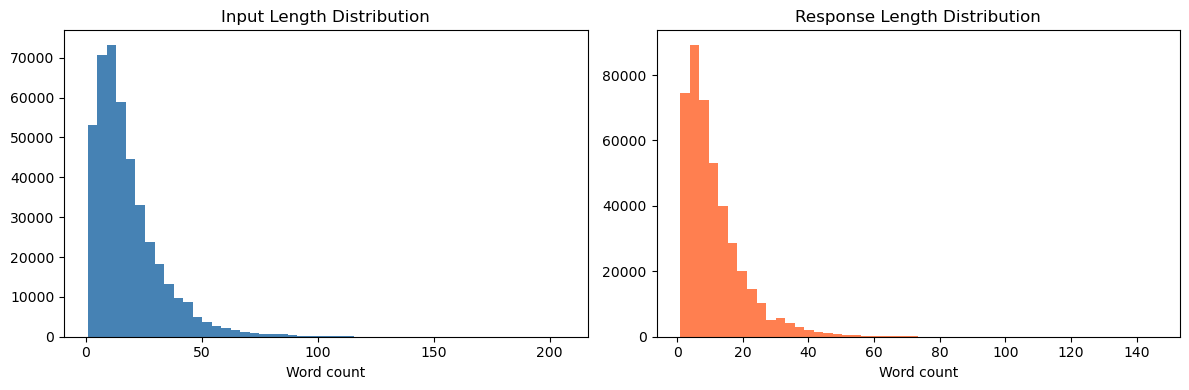

In [52]:
import matplotlib.pyplot as plt

pairs_df['input_len'] = pairs_df['input'].apply(lambda x: len(x.split()))
pairs_df['response_len'] = pairs_df['response'].apply(lambda x: len(x.split()))

print(pairs_df[['input_len', 'response_len']].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(pairs_df['input_len'], bins=50, color='steelblue')
plt.title('Input Length Distribution')
plt.xlabel('Word count')

plt.subplot(1, 2, 2)
plt.hist(pairs_df['response_len'], bins=50, color='coral')
plt.title('Response Length Distribution')
plt.xlabel('Word count')

plt.tight_layout()
plt.savefig('visualisations/1-dialogue-pair-text-lengths.png')
plt.show()

In [51]:
pairs_df['input_len'] = pairs_df['input'].apply(lambda x: len(str(x).split()))
pairs_df['response_len'] = pairs_df['response'].apply(
    lambda x: len(str(x).split()))

filtered_df = pairs_df[
    (pairs_df['input_len'] >= MIN_LENGTH) &
    (pairs_df['response_len'] >= MIN_LENGTH) &
    (pairs_df['input_len'] <= MAX_LENGTH) &
    (pairs_df['response_len'] <= MAX_LENGTH)
].reset_index(drop=True)

filtered_df = filtered_df.drop(columns=['input_len', 'response_len'])
print(f'Pairs before filtering: {len(pairs_df)}')
print(f'Pairs after filtering:  {len(filtered_df)}')
print(f'Retained: {len(filtered_df)/len(pairs_df)*100:.1f}%')
filtered_df.head(10)
filtered_df.head(5)

Pairs before filtering: 428675
Pairs after filtering:  279567
Retained: 65.2%


,input,response
0,<user> sock puppe?t <user> wtf?,"<user> it's a wikipedia term. there is prodigy, prdigy and prgidy and they're all the same guy"
1,<user> probably not a vector icon,<user> the other icons aren't vector icons either.
2,<user> how do fix vlc in the terminal?,<user> fix what? <user> check other programs. same faint sound?
3,"<user> ok, anyone know how i set bios password in ubuntu <user> already set",<user> you'd need to set that in your bios.
4,<user> how do i generate an xorg.conf file? <user> for intel gmas,"<user> '<cmd> xorg -configure', i think"


## Train/Validation/Test Splits


In [53]:
# Split the test set
train_val_df, test_df = train_test_split(
    filtered_df, test_size=0.1, random_state=42)

# Split the validation set
train_df, val_df = train_test_split(
    train_val_df, test_size=0.1, random_state=42)

print(
    f'Train:\t\t{len(train_df)} pairs ({len(train_df)/len(filtered_df)*100:.1f}%)')
print(
    f'Validation:\t{len(val_df)} pairs ({len(val_df)/len(filtered_df)*100:.1f}%)')
print(
    f'Test:\t\t{len(test_df)} pairs ({len(test_df)/len(filtered_df)*100:.1f}%)')

Train:		226449 pairs (81.0%)
Validation:	25161 pairs (9.0%)
Test:		27957 pairs (10.0%)


## Dataset Split Distribution Check

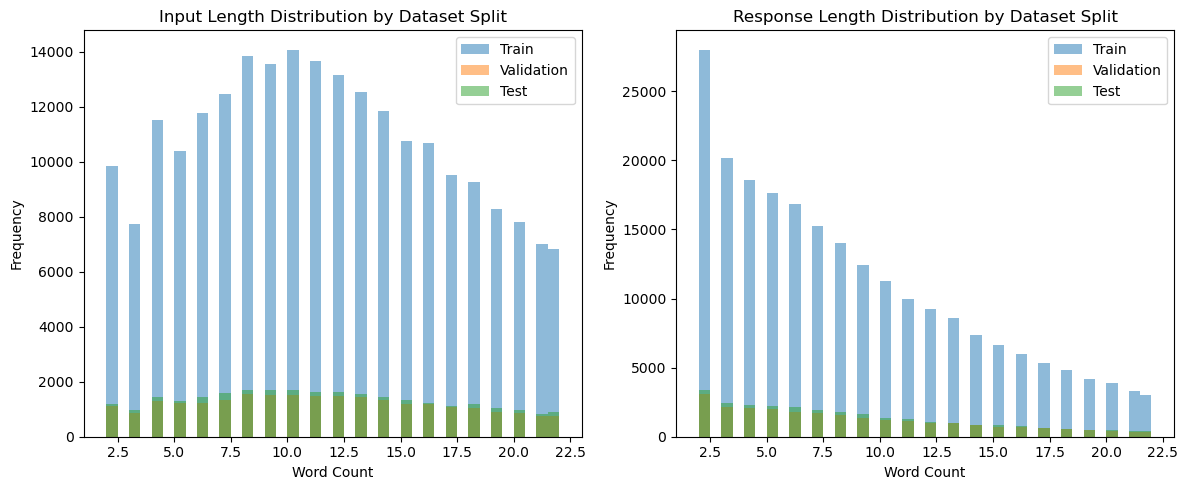

In [54]:
import matplotlib.pyplot as plt

# Compute input lengths
train_input_len = train_df['input'].apply(lambda x: len(x.split()))
val_input_len = val_df['input'].apply(lambda x: len(x.split()))
test_input_len = test_df['input'].apply(lambda x: len(x.split()))

# Compute response lengths
train_resp_len = train_df['response'].apply(lambda x: len(x.split()))
val_resp_len = val_df['response'].apply(lambda x: len(x.split()))
test_resp_len = test_df['response'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))

# Input length comparison
plt.subplot(1, 2, 1)
plt.hist(train_input_len, bins=40, alpha=0.5, label="Train")
plt.hist(val_input_len, bins=40, alpha=0.5, label="Validation")
plt.hist(test_input_len, bins=40, alpha=0.5, label="Test")
plt.title("Input Length Distribution by Dataset Split")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()

# Response length comparison
plt.subplot(1, 2, 2)
plt.hist(train_resp_len, bins=40, alpha=0.5, label="Train")
plt.hist(val_resp_len, bins=40, alpha=0.5, label="Validation")
plt.hist(test_resp_len, bins=40, alpha=0.5, label="Test")
plt.title("Response Length Distribution by Dataset Split")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

## Output Training CSV

In [55]:
train_csv = f'{PREPROCESSED_DIR}/train.csv'
val_csv = f'{PREPROCESSED_DIR}/val.csv'
test_csv = f'{PREPROCESSED_DIR}/test.csv'

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

print("Saved split CSVs.")

Saved split CSVs.


## Build BPE Vocab

In [59]:
bpe = None
bpe_vocab_size = None

if USE_BPE:
    print("Training BPE...")
    bpe = train_bpe(
        train_csv_path=train_csv,
        output_dir=BPE_DIR,
        vocab_size=BPE_VOCAB_SIZE,
        min_frequency=BPE_MIN_FREQ
    )
    bpe_vocab_size = bpe.get_vocab_size()
    print("BPE vocab size:", bpe_vocab_size)
else:
    print("USE_BPE=False")

Training BPE...



BPE vocab size: 16000


### Save BPE Configuration

In [60]:
config = {
    "TOKENIZER_MODE": "bpe" if USE_BPE else "word",
    "SPECIAL_TOKENS": SPECIAL_TOKENS,

    "MAX_LENGTH": MAX_LENGTH,
    "MIN_LENGTH": MIN_LENGTH,
    "BATCH_SIZE": BATCH_SIZE,

    "TRAIN_SIZE": len(train_df),
    "VAL_SIZE": len(val_df),
    "TEST_SIZE": len(test_df),

    "BPE_DIR": BPE_DIR if USE_BPE else None,
    "BPE_VOCAB_SIZE": bpe_vocab_size,
    "BPE_TARGET_VOCAB_SIZE": BPE_VOCAB_SIZE if USE_BPE else None,
    "BPE_MIN_FREQ": BPE_MIN_FREQ if USE_BPE else None,
}

with open(f'{PREPROCESSED_DIR}/config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print("Saved config.json")
print(config)

Saved config.json
{'TOKENIZER_MODE': 'bpe', 'SPECIAL_TOKENS': ['<PAD>', '<SOS>', '<EOS>', '<UNK>', '<SEP>', '<S0>', '<S1>', '<url>', '<path>', '<ip>', '<user>', '<version>', '<email>', '<cmd>'], 'MAX_LENGTH': 22, 'MIN_LENGTH': 2, 'BATCH_SIZE': 64, 'TRAIN_SIZE': 226449, 'VAL_SIZE': 25161, 'TEST_SIZE': 27957, 'BPE_DIR': './data/bpe', 'BPE_VOCAB_SIZE': 16000, 'BPE_TARGET_VOCAB_SIZE': 16000, 'BPE_MIN_FREQ': 2}
